In [ ]:
#project: Predicting Diabetic Retinopathy
#Yazeed Almazyad

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
#contains data for 20k patients, with 10 columns describing various health metrics and conditions.
#the data was obtained from kaggel
#reading the dataset
df = pd.read_csv('patient_data.csv')

#shows data types and non-null counts
print(df.info())
print(df.describe())

#features: handle blood pressure
#the data for blood pressure was a string so we convert it to two integars
#"high" and "low" blood pressure
df[['high_bp', 'low_bp']] = df['blood_pressure'].str.split('/', expand=True).astype(int)

#drop columns that won't be used
df.drop(columns=['name', 'blood_pressure'], inplace=True)

#encode boolean data
le = LabelEncoder()
df['has_eye_disease'] = le.fit_transform(df['has_eye_disease'])
df['has_diabetic_retinopathy'] = le.fit_transform(df['has_diabetic_retinopathy'])

#check for missing values, if found the whole row is dropped
if df.isnull().sum().sum() > 0:
    df.dropna(inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   name                      20000 non-null  object 
 1   age                       20000 non-null  int64  
 2   has_eye_disease           20000 non-null  bool   
 3   has_diabetic_retinopathy  20000 non-null  bool   
 4   sugar_percentage          20000 non-null  float64
 5   glucose_percentage        20000 non-null  float64
 6   cholesterol_percentage    20000 non-null  float64
 7   obesity_percentage        20000 non-null  float64
 8   blood_pressure            20000 non-null  object 
 9   heart_rate                20000 non-null  int64  
dtypes: bool(2), float64(4), int64(2), object(2)
memory usage: 1.3+ MB
None
                age  sugar_percentage  glucose_percentage  \
count  20000.000000      20000.000000        20000.000000   
mean      54.924350          9.48

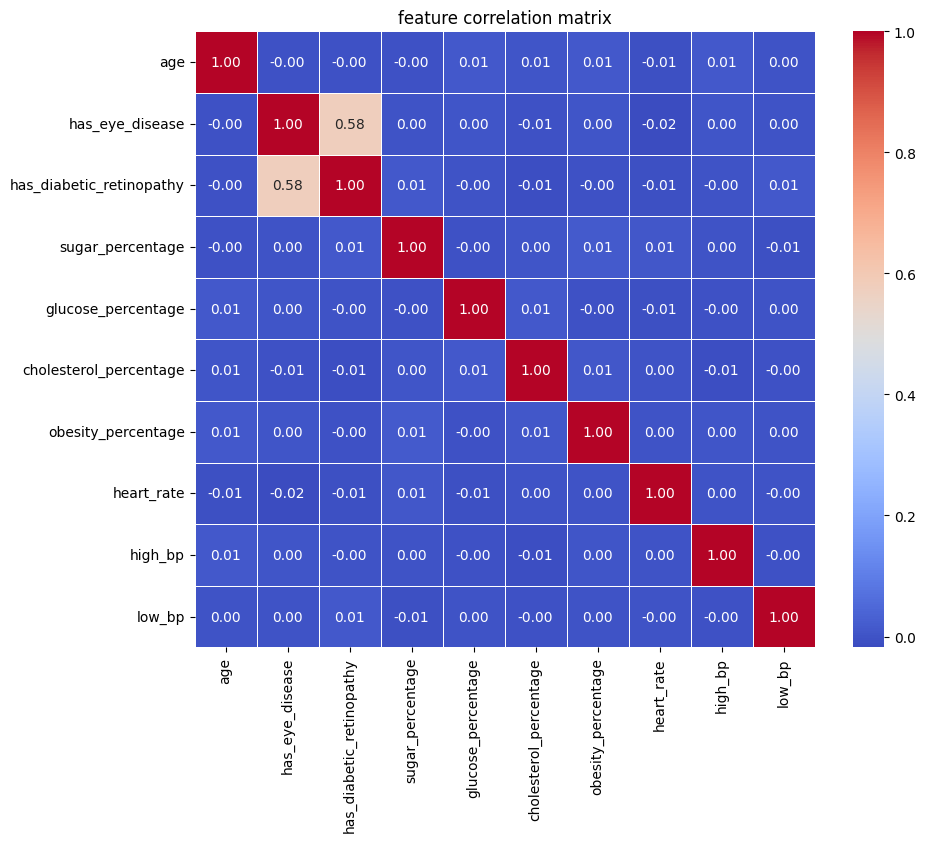

In [ ]:
corr = df.corr()

#plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('feature correlation matrix')
plt.show()

In [ ]:
#feature Scaling and Splitting
#define features (X) and target (y)
X = df.drop(columns=['has_diabetic_retinopathy'])
y = df['has_diabetic_retinopathy']

#split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
#logistic regression model

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

print("accuracy for logistic regression model:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


accuracy for logistic regression model: 0.75475
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      3002
           1       0.51      0.42      0.46       998

    accuracy                           0.75      4000
   macro avg       0.66      0.64      0.65      4000
weighted avg       0.74      0.75      0.75      4000



In [ ]:
#decision tree model

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)


print("accuracy for decision tree model:", accuracy_score(y_test, y_pred_dt))


accuracy for decision tree model: 0.741


In [ ]:
#hyperparameter Tuning


#loop function to find best depth to prevent overfitting
best_acc = 0
best_depth = 0
for d in [3, 5, 7, 10, 15, 20]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    if acc > best_acc:
        best_acc = acc
        best_depth = d

print(f"best max depth found: {best_depth}")

#train final optimized Tree
best_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_tree.fit(X_train, y_train)
y_pred_best = best_tree.predict(X_test)

print("\n optimized decision tree results: ")
print("accuracy for optimized decision tree: ", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


best max depth found: 10

 optimized decision tree results: 
accuracy for optimized decision tree:  0.75625
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      3002
           1       0.51      0.51      0.51       998

    accuracy                           0.76      4000
   macro avg       0.67      0.67      0.67      4000
weighted avg       0.76      0.76      0.76      4000



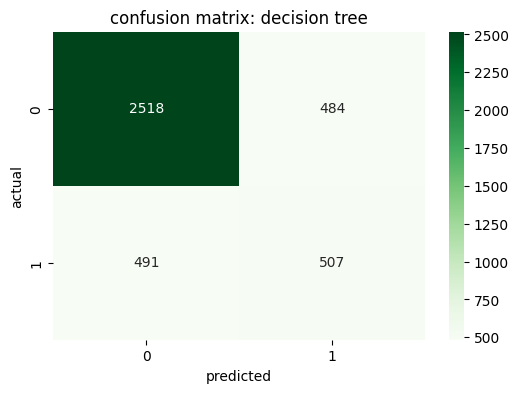


 feature ranking:
1. has_eye_disease (0.8156)
2. cholesterol_percentage (0.0331)
3. glucose_percentage (0.0312)
4. sugar_percentage (0.0298)
5. obesity_percentage (0.0256)
6. high_bp (0.0209)
7. age (0.0208)
8. low_bp (0.0123)
9. heart_rate (0.0107)


In [ ]:
#visualizing using confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('confusion matrix: decision tree')
plt.ylabel('actual')
plt.xlabel('predicted')
plt.show()

#feature importance
importances = best_tree.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

print("\n feature ranking:")
for f in range(X.shape[1]):
    print(f"{f + 1}. {features[indices[f]]} ({importances[indices[f]]:.4f})")

#beacus of this ranking:
#1:we can see that "has_eye_disease" is the most feature
#  that effect the modle results
#2:we can also see that "cholesterol_percentage" has the most effect (in term
#  of other factors besaid having the disease)